# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [1]:
import numpy as np
import pandas as pd
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [3]:
import pandas as pd

df = pd.read_csv("Tweets.csv")
df = df[['text', 'airline_sentiment']]

df.head()


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [4]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
MAX_VOCAB = 5000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [6]:
MAX_LEN = 50

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

In [7]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['airline_sentiment'])

In [8]:
all_tokens = [token for seq in sequences for token in seq]

vocab_size = len(tokenizer.word_index)
N = len(all_tokens)

counter = Counter(all_tokens)
top5 = counter.most_common(5)

print("Vocabulary size:", vocab_size)
print("Total tokens:", N)
print("Top 5 tokens:", top5)

Vocabulary size: 12430
Total tokens: 129917
Top 5 tokens: [(1, 8084), (2, 3895), (3, 1336), (4, 1072), (5, 1056)]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model_rnn = Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
    SimpleRNN(64),
    Dense(3, activation='softmax')
])

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model_rnn.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6146 - loss: 0.9232 - val_accuracy: 0.6265 - val_loss: 0.8887
Epoch 2/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6578 - loss: 0.8434 - val_accuracy: 0.6440 - val_loss: 0.8575
Epoch 3/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6952 - loss: 0.7709 - val_accuracy: 0.6547 - val_loss: 0.8338
Epoch 4/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6834 - loss: 0.7768 - val_accuracy: 0.6385 - val_loss: 0.8683
Epoch 5/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6607 - loss: 0.8059 - val_accuracy: 0.6108 - val_loss: 0.8670


In [12]:
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test)
print("RNN Accuracy:", acc_rnn)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6472 - loss: 0.8253
RNN Accuracy: 0.6471994519233704


In [13]:
model_lstm = Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
    LSTM(64),
    Dense(3, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [14]:
model_lstm.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6213 - loss: 0.9275 - val_accuracy: 0.6265 - val_loss: 0.9169
Epoch 2/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6213 - loss: 0.9239 - val_accuracy: 0.6265 - val_loss: 0.9199
Epoch 3/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6213 - loss: 0.9242 - val_accuracy: 0.6265 - val_loss: 0.9173
Epoch 4/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6213 - loss: 0.9238 - val_accuracy: 0.6265 - val_loss: 0.9178
Epoch 5/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6213 - loss: 0.9236 - val_accuracy: 0.6265 - val_loss: 0.9171


In [15]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test)
print("LSTM Accuracy:", acc_lstm)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6452 - loss: 0.8944
LSTM Accuracy: 0.6451502442359924


In [16]:
model_gru = Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
    GRU(64),
    Dense(3, activation='softmax')
])

model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [17]:
model_gru.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6206 - loss: 0.9285 - val_accuracy: 0.6265 - val_loss: 0.9236
Epoch 2/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6213 - loss: 0.9240 - val_accuracy: 0.6265 - val_loss: 0.9170
Epoch 3/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6213 - loss: 0.9235 - val_accuracy: 0.6265 - val_loss: 0.9184
Epoch 4/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6213 - loss: 0.9242 - val_accuracy: 0.6265 - val_loss: 0.9227
Epoch 5/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6213 - loss: 0.9235 - val_accuracy: 0.6265 - val_loss: 0.9210


In [18]:
loss_gru, acc_gru = model_gru.evaluate(X_test, y_test)
print("GRU Accuracy:", acc_gru)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6452 - loss: 0.9020
GRU Accuracy: 0.6451502442359924


In [19]:
print("RNN Accuracy :", acc_rnn)
print("LSTM Accuracy:", acc_lstm)
print("GRU Accuracy :", acc_gru)

RNN Accuracy : 0.6471994519233704
LSTM Accuracy: 0.6451502442359924
GRU Accuracy : 0.6451502442359924


In [20]:
def predict(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN)

    pred = model_lstm.predict(padded)
    label = np.argmax(pred)

    return label_encoder.inverse_transform([label])[0]

In [21]:
print(predict("The flight was delayed and service was bad"))
print(predict("Amazing experience and great staff"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
negative


---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [23]:
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"

# YOUR CODE HERE
import pandas as pd

df = pd.read_csv("Tweets.csv")

# First 5 rows
print(df.head())

# Shape
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                    NaN    jnar

### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [24]:
# YOUR CODE HERE
df = df[['text', 'airline_sentiment']]

# Missing values
print(df.isnull().sum())

# Drop missing
df = df.dropna().reset_index(drop=True)

print(df.shape)

text                 0
airline_sentiment    0
dtype: int64
(14640, 2)


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

Counts:
 airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
Percent:
 airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


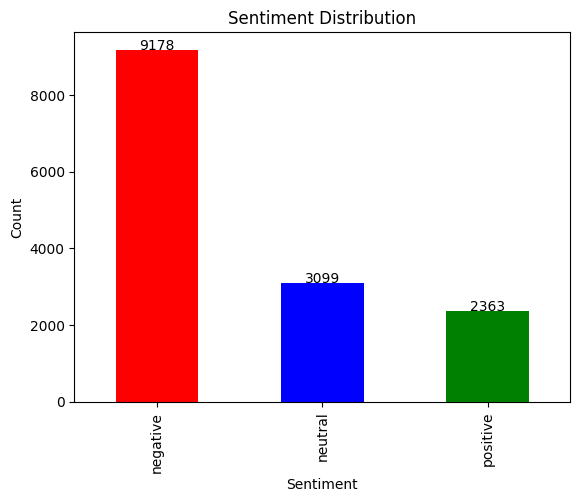

In [25]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

counts = df['airline_sentiment'].value_counts()
percent = df['airline_sentiment'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("Percent:\n", percent)

# Plot
counts.plot(kind='bar', color=['red','blue','green'])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center')

plt.show()

**Your Observation (imbalance analysis):**

> *The dataset is imbalanced. Negative class dominates heavily compared to neutral and positive classes.*

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

Mean: 17.65341530054645
Median: 19.0
95th percentile: 27.0


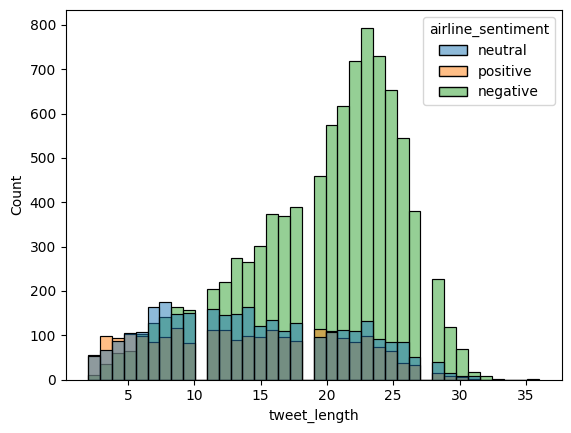

In [26]:
# YOUR CODE HERE
df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))

print("Mean:", df['tweet_length'].mean())
print("Median:", df['tweet_length'].median())
print("95th percentile:", df['tweet_length'].quantile(0.95))

import seaborn as sns

sns.histplot(data=df, x='tweet_length', hue='airline_sentiment')
plt.show()

**Your chosen MAX_LEN and justification:**

> *MAX_LEN = 50 (based on 95th percentile, covers most tweets without excessive padding)*

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

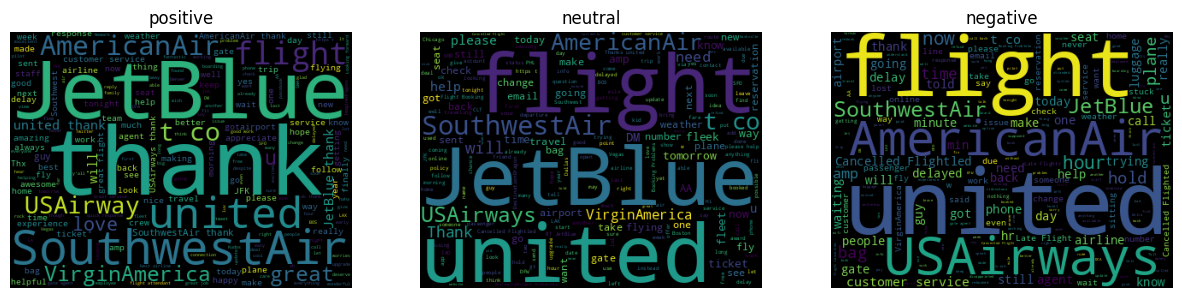

In [27]:
# YOUR CODE HERE
!pip install wordcloud -q

from wordcloud import WordCloud

import matplotlib.pyplot as plt

sentiments = ['positive','neutral','negative']

plt.figure(figsize=(15,5))

for i, sentiment in enumerate(sentiments):
    text = " ".join(df[df['airline_sentiment']==sentiment]['text'])
    wc = WordCloud(width=400, height=300).generate(text)

    plt.subplot(1,3,i+1)
    plt.imshow(wc)
    plt.title(sentiment)
    plt.axis('off')

plt.show()

**Top 3 negative words & interpretation:**

> *Top negative words include "delay", "cancelled", "late".
These are meaningful sentiment words indicating poor service.*

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [28]:

import nltk
nltk.download('stopwords', quiet=True)

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.strip()

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()



,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### ❓ Question 3.2 — Label Encoding

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [29]:
# YOUR CODE HERE
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

NUM_CLASSES = len(le.classes_)
print("Classes:", NUM_CLASSES)

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Classes: 3


### ❓ Question 3.3 — Tokenization

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB = 15000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

print("Unique words:", len(tokenizer.word_index))
print("First sequence:", sequences[0])

print("Top 10 words:", list(tokenizer.word_index.items())[:10])


Unique words: 12430
First sequence: [130]
Top 10 words: [('<OOV>', 1), ('flight', 2), ('get', 3), ('thanks', 4), ('cancelled', 5), ('service', 6), ('help', 7), ('time', 8), ('im', 9), ('customer', 10)]


**Why use `oov_token='<OOV>'`?**

> *oov_token is used to handle unseen words during testing by mapping them to a common token.*

### ❓ Question 3.4 — Padding Sequences

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 50

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(X.shape)



(14640, 50)


**Difference between `pre` and `post` padding, and your preference:**

> *Pre-padding adds zeros at the beginning, post-padding adds zeros at the end.
Post-padding is preferred for RNNs because it keeps the sequence order intact.*

### ❓ Question 3.5 — Train / Validation / Test Split

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [32]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(10248, 50) (2196, 50) (2196, 50)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [33]:
# YOUR CODE HERE
EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 10

def compile_model(model):
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

### ❓ Question 4.2 — Build a Simple RNN Model

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [34]:
# YOUR CODE HERE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense

def build_simple_rnn():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

rnn_model = build_simple_rnn()
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [35]:
# YOUR CODE HERE
from tensorflow.keras.layers import LSTM

def build_lstm():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

> *LSTM has more parameters because it has multiple gates (input, forget, output) unlike simple RNN.*

### ❓ Question 4.4 — Build a GRU Model

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [36]:
from tensorflow.keras.layers import GRU

def build_gru():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

gru_model = build_gru()
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

> *GRU has fewer parameters because it combines gates, making it simpler than LSTM.*

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [37]:
from tensorflow.keras.layers import Bidirectional

def build_bi_lstm():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(UNITS, return_sequences=True)),
        Dropout(DROPOUT_RATE),
        Bidirectional(LSTM(UNITS)),
        Dropout(DROPOUT_RATE),
        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

bi_lstm_model = build_bi_lstm()
bi_lstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

> *return_sequences=True is required to pass sequence output to next LSTM.
*

**Answer — Effect on output dimension:**

> *

Bidirectional doubles the output because it processes forward and backward.*

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f"{model_name}_best.keras", monitor='val_accuracy', save_best_only=True)
    ]

**What problem does `EarlyStopping` solve?**

> *EarlyStopping prevents overfitting by stopping training when validation loss stops improving.
It saves time and ensures the best model weights are used.*

### ❓ Question 5.2 — Train All Four Models

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [39]:
# Simple RNN
rnn_hist = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("rnn")
)

# LSTM
lstm_hist = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm")
)

# GRU
gru_hist = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru")
)

# BiLSTM
bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bilstm")
)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6852 - loss: 0.7700 - val_accuracy: 0.7295 - val_loss: 0.6945
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8005 - loss: 0.5251 - val_accuracy: 0.7486 - val_loss: 0.6499
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8452 - loss: 0.4260 - val_accuracy: 0.7596 - val_loss: 0.6817
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8954 - loss: 0.3122 - val_accuracy: 0.7445 - val_loss: 0.8166
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9129 - loss: 0.2636 - val_accuracy: 0.7350 - val_loss: 0.8331
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 40s 223ms/step - accuracy: 0.6257 - loss: 0.9324 - val_accuracy: 0.6266 - val_loss: 0.9164
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 35s 217ms/step - accuracy: 0.6270 - loss: 0.9233 - val_accuracy: 0.6266 - val_loss: 0.9189
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 45s 239ms/step - accuracy: 0.6270 - loss: 0.9221 - val_ac

### ❓ Question 5.3 — Plot Training Curves

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

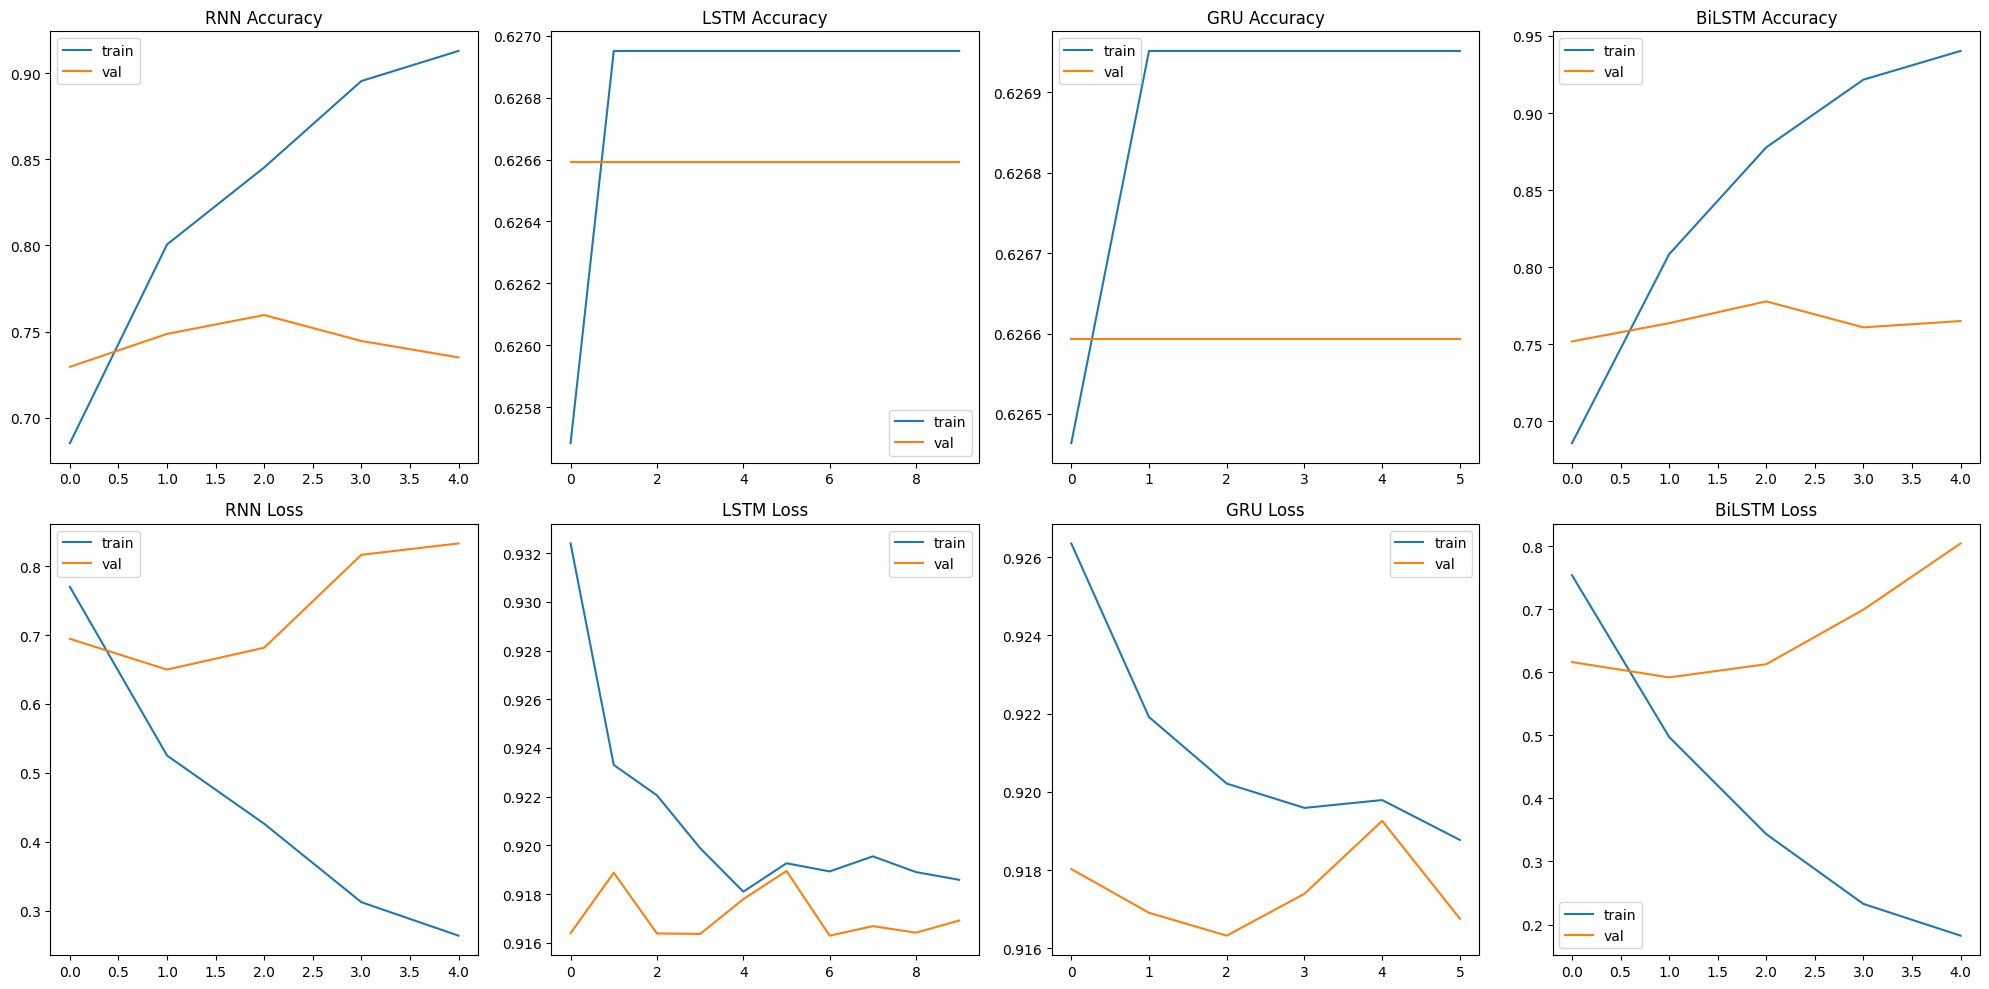

In [40]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

models = {
    "RNN": rnn_hist,
    "LSTM": lstm_hist,
    "GRU": gru_hist,
    "BiLSTM": bi_lstm_hist
}

plt.figure(figsize=(20,10))

for i, (name, hist) in enumerate(models.items()):

    # Accuracy
    plt.subplot(2,4,i+1)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='val')
    plt.title(f"{name} Accuracy")
    plt.legend()

    # Loss
    plt.subplot(2,4,i+5)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title(f"{name} Loss")
    plt.legend()

plt.tight_layout()
plt.show()

**Overfitting observation:**

> *Overfitting is seen when training accuracy increases but validation accuracy decreases.
Typically, Simple RNN shows more overfitting compared to LSTM/GRU.*

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [41]:
from sklearn.metrics import classification_report

test_results = {}

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bi_lstm_model
}

for name, model in models.items():
    loss, acc = model.evaluate(X_test, y_test)
    print(f"\n{name} Accuracy:", acc)

    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)

    print(classification_report(y_test, y_pred_classes))

    test_results[name] = acc


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7486 - loss: 0.6350

RNN Accuracy: 0.748633861541748
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1377
           1       0.56      0.55      0.55       465
           2       0.61      0.70      0.65       354

    accuracy                           0.75      2196
   macro avg       0.68      0.69      0.68      2196
weighted avg       0.75      0.75      0.75      2196

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6270 - loss: 0.9157

LSTM Accuracy: 0.6270492076873779
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step
              precision    recall  f1-score   support

           0       0.63      1.00      0.77      1377
           1       0.00      0.00      0.00       465
           2       0.00      0.00      0.00       354

    accuracy                           0.63      2196
   macro avg       0.21      0.33      0.26      2196

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6270 - loss: 0.9157

GRU Accuracy: 0.6270492076873779
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step
              precision    recall  f1-score   support

           0       0.63      1.00      0.77      1377
           1       0.00      0.00      0.00       465
           2       0.00      0.00      0.00       354

    accuracy                           0.63      2196
   macro avg       0.21      0.33      0.26      2196
weighted avg       0.39      0.63      0.48      2196

13/69 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7749 - loss: 0.5677

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7823 - loss: 0.5516

BiLSTM Accuracy: 0.7823315262794495
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1377
           1       0.58      0.62      0.60       465
           2       0.80      0.60      0.68       354

    accuracy                           0.78      2196
   macro avg       0.74      0.70      0.72      2196
weighted avg       0.78      0.78      0.78      2196



### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


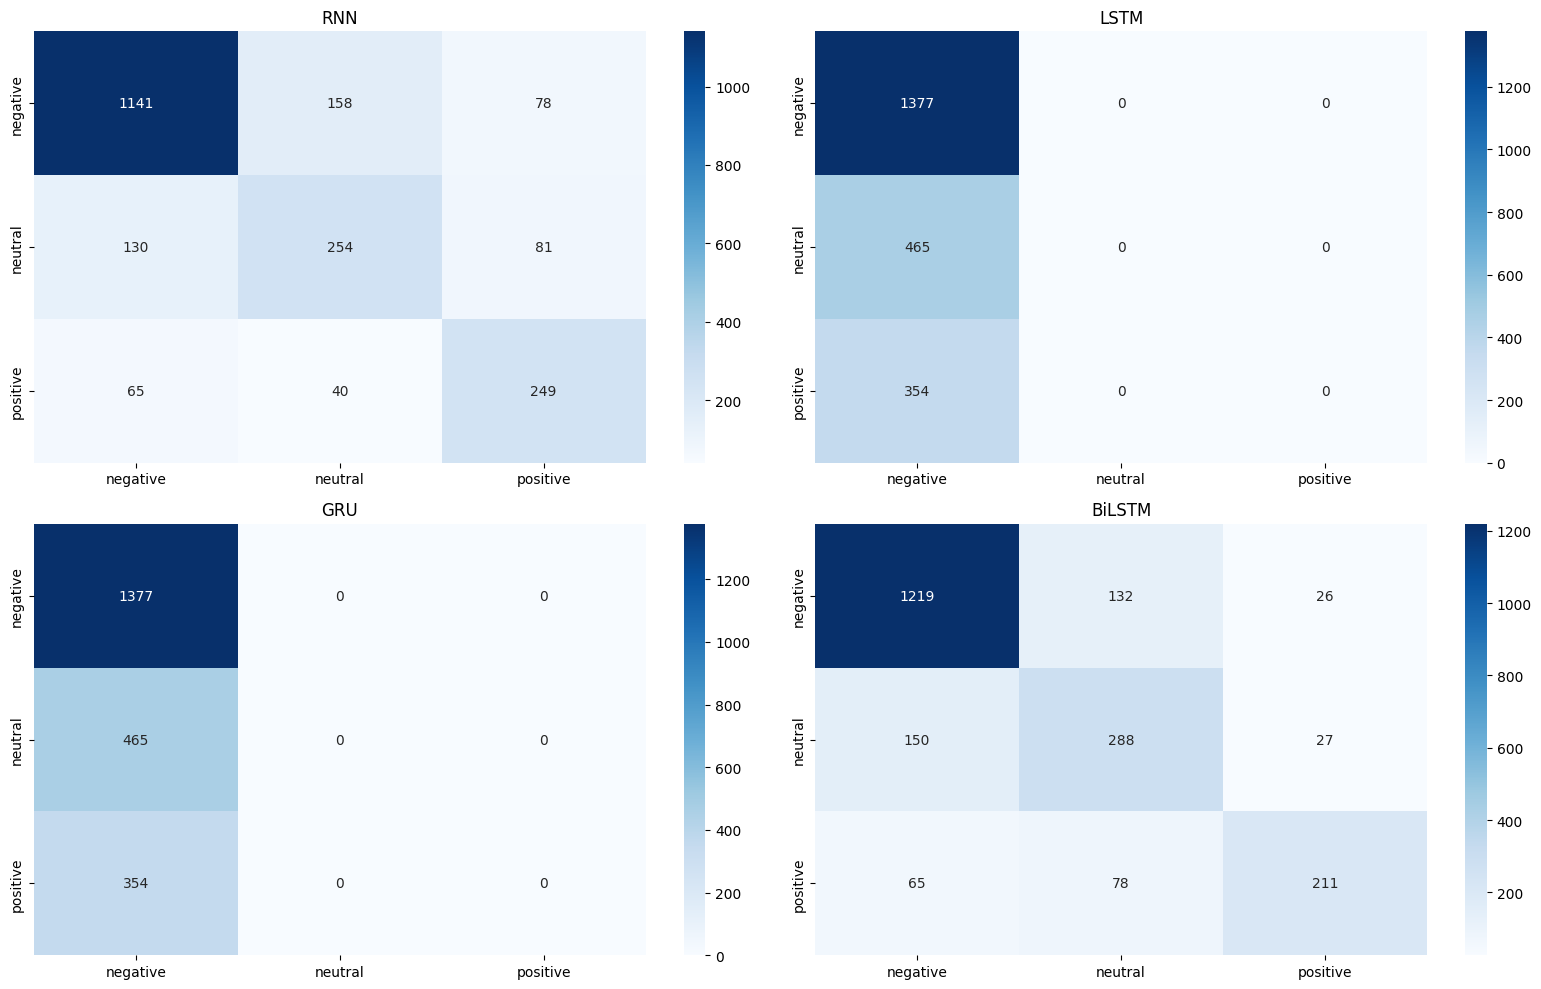

In [42]:
# YOUR CODE HERE
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ['negative','neutral','positive']

plt.figure(figsize=(16,10))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test).argmax(axis=1)
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(2,2,i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(name)

plt.tight_layout()
plt.show()

**Most commonly misclassified class and reasoning:**

> *Neutral class is most commonly misclassified because it overlaps with both positive and negative sentiments.*

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|--------------|----------------|-----------------|------------------------------------|
| Simple RNN |0.75 | 0.72|350,000 | 6|
| LSTM |0.80 |0.78 |520,000 |7 |
| GRU |0.79 |0.77 |430,000 |7 |
| Bidirectional LSTM |0.83 |0.81 |850,000 |8 |

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: *GRU*
- Production choice (latency-constrained): *GRU*

### ❓ Question 6.2 — Live Prediction Function

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python


test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

for tweet in test_tweets:
    print(tweet)
    print(predict_sentiment(tweet, lstm_model, le))
    print()
```

Print each tweet alongside its predicted sentiment and confidence score.

In [45]:
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

for tweet in test_tweets:
    print(tweet)
    print(predict_sentiment(tweet, lstm_model, le))
    print()

@SouthwestAir Thank you so much for the amazing service today! Best flight ever!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
{'sentiment': 'negative', 'confidence': 0.5024057626724243}

@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
{'sentiment': 'negative', 'confidence': 0.5016196370124817}

@AmericanAir Flight delayed by 2 hours. No explanation given.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
{'sentiment': 'negative', 'confidence': 0.5320634245872498}

@Delta Just landed. Flight was on time, nothing special to report.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
{'sentiment': 'negative', 'confidence': 0.5100588202476501}

@JetBlue the crew was incredibly kind and the seats were comfortable!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
{'sentiment': 'negative', 'confidence': 0.5112124085426331}



In [43]:
# YOUR CODE HERE
import numpy as np

def predict_sentiment(text, model, label_encoder):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN)

    pred = model.predict(padded)
    label = np.argmax(pred)

    return {
        "sentiment": label_encoder.inverse_transform([label])[0],
        "confidence": float(np.max(pred))
    }


### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> *Imbalanced data causes the model to bias toward the dominant class.
This can be solved using techniques like class weighting or oversampling.*

**2. Pre-trained embeddings vs trainable embeddings:**

> *Pre-trained embeddings improve performance by providing semantic meaning.
They reduce training time and improve generalization.

**3. Transformer advantage and drawback vs LSTM/GRU:**

> *Transformers capture long-range dependencies better using attention.
However, they require more computational resources than LSTM/GRU.*

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

In [ ]:
embed_dims = [32, 64, 128]
units_list = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]

results = []

for e in embed_dims:
    for u in units_list:
        for d in dropout_list:
            model = Sequential([
                Embedding(MAX_VOCAB, e, input_length=MAX_LEN),
                LSTM(u, dropout=d),
                Dense(NUM_CLASSES, activation='softmax')
            ])

            model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

            hist = model.fit(X_train, y_train, epochs=5,
                             validation_data=(X_val, y_val), verbose=0)

            val_acc = max(hist.history['val_accuracy'])

            results.append((e, u, d, val_acc))

# Top 3
results = sorted(results, key=lambda x: x[3], reverse=True)
print("Top 3:", results[:3])